In [1]:
# Import required libraries for deep learning and visualization
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

print("OK")

OK


In [2]:
# Define dataset location
dataset_path = "data/PetImages"

In [3]:
# Load images from folders and automatically create labels from folder names
# Cat = one class, Dog = another class

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [4]:
# Display class names detected from folders
class_names = train_data.class_names
print(class_names)

['Cat', 'Dog']


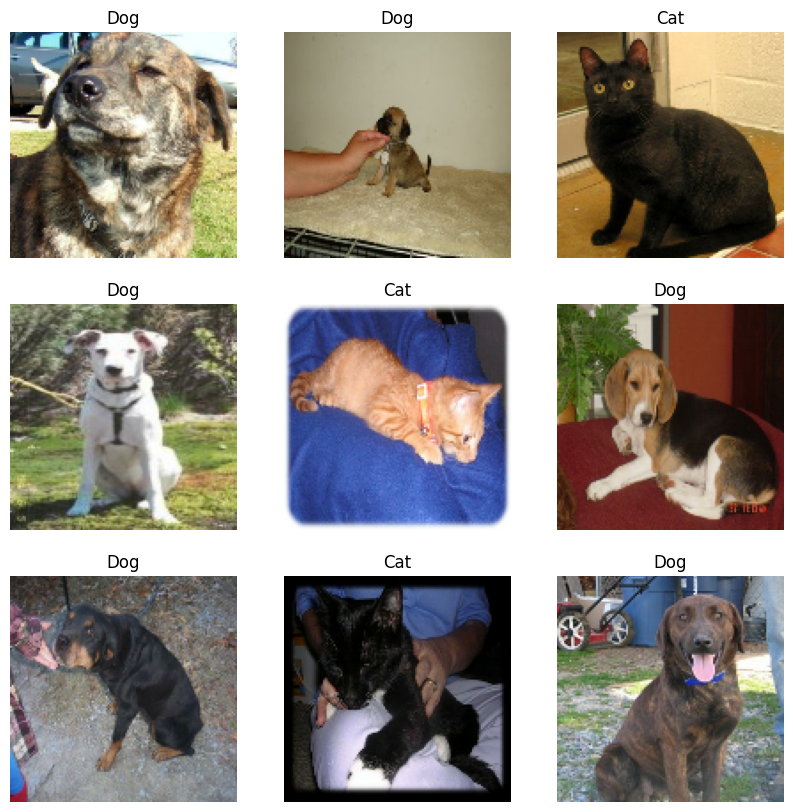

In [5]:
# Display several images from the training dataset
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
# Improve dataset loading performance
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
# Build a Convolutional Neural Network for binary image classification

from tensorflow.keras import layers, models

model = models.Sequential([

    # Define input layer explicitly
    layers.Input(shape=(128, 128, 3)),

    # Normalize pixel values
    layers.Rescaling(1./255),

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten feature maps
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    layers.Dropout(0.3),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the CNN model
# Binary crossentropy is used because there are only two classes: Cat and Dog

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Find and remove images that TensorFlow cannot decode

import os
import tensorflow as tf

dataset_path = "data/PetImages"
bad_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        file_path = os.path.join(root, file)

        try:
            image_bytes = tf.io.read_file(file_path)
            image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
        except Exception as e:
            bad_files.append(file_path)

print("Bad files found:", len(bad_files))

for file_path in bad_files:
    print("Removing:", file_path)
    os.remove(file_path)

print("Bad files removed.")

Bad files found: 0
Bad files removed.


In [10]:
# Train the model and validate it after each epoch

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 99ms/step - accuracy: 0.6530 - loss: 0.6113 - val_accuracy: 0.7463 - val_loss: 0.5136
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.7643 - loss: 0.4867 - val_accuracy: 0.8045 - val_loss: 0.4214
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 105ms/step - accuracy: 0.8112 - loss: 0.4135 - val_accuracy: 0.8281 - val_loss: 0.3939
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.8478 - loss: 0.3424 - val_accuracy: 0.8393 - val_loss: 0.3681
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 113ms/step - accuracy: 0.8819 - loss: 0.2784 - val_accuracy: 0.8517 - val_loss: 0.3555
